
Transformer bloğunu parça parça tamamla: feedforward, residual bağlantı, LayerNorm. Her parçayı ekledikten sonra val loss'u kaydet. Tek tablo çıkar: bigram, tek head, multi-head, feedforward eklenmiş, residual eklenmiş, LayerNorm eklenmiş. LayerNorm'u hafta 6'da yazdığın BatchNorm1d ile karşılaştır: hangi eksende normalize ediyor, neden running_mean tutmuyor, kendi cümlelerinle yaz. (1:24:25 - 1:37:49)

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import pandas as pd

In [ ]:
batch_size = 32
block_size = 8
max_iters = 3000
eval_interval = 300
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 32
n_head=4
n_layer = 6  
dropout = 0.2

torch.manual_seed(42)

In [3]:
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [4]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

In [5]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

In [6]:
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

In [7]:
@torch.no_grad()
def estimate_loss(model):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out


In [8]:
print(f"Cihaz: {device}, Vocab Size: {vocab_size}, n_embd: {n_embd}")

Cihaz: cuda, Vocab Size: 65, n_embd: 32


### Self-Attention Head Sınıfı

In [9]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)   # (B, T, head_size)
        q = self.query(x) # (B, T, head_size)

        # Attention score
        wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5) # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)

        # ağırlıklı toplam
        v = self.value(x) # (B, T, head_size)
        out = wei @ v     # (B, T, head_size)
        return out

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out

In [ ]:
class FeedFoward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(), #Gelen değerlerden sıfırın altında olanları 0 yapar, pozitif olanları olduğu gibi geçirir.
            nn.Linear(4 * n_embd, n_embd)# Residual connection için boyut düşürme 
        )

    def forward(self, x):
        return self.net(x)

### Transformer block

In [ ]:
class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        # Katmanlar arasındaki bağlantıyı sıfırdan öğrenmek zorunda kalmadan eğitime odaklanıyor ve vanishing gradient sorununu ortada kaldırıyor
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

### Self-attention'lı Bigram Modeli

In [11]:
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.sa_head = MultiHeadAttention(n_head,n_embd // n_head)         
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)


    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx) # (B, T, n_embd)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T, n_embd)
        x = tok_emb + pos_emb # (B, T, n_embd)

        # Self-attention uygula
        x = self.sa_head(x) # (B, T, n_embd)
        x = self.ln_f(x) # (B,T,C)
        # Logitleri üret
        logits = self.lm_head(x) # (B, T, vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx: (B, T) boyutunda mevcut context
        for _ in range(max_new_tokens):
            # position embedding sınırını aşmamak için son 8 karaktere bakıyoruz
            idx_cond = idx[:, -block_size:]
            logits, loss = self(idx_cond)
            logits = logits[:, -1, :] # (B, C)
            probs = F.softmax(logits, dim=-1) # (B, C)
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

### Modelin Eğitilmesi

In [32]:
torch.manual_seed(42)
model = BigramLanguageModel().to(device)
print(f"Toplam parameter: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss(model)
        print(f"{iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

Toplam parameter: 8,673
0: train loss 4.4859, val loss 4.4817
300: train loss 2.6567, val loss 2.6756
600: train loss 2.5012, val loss 2.5025
900: train loss 2.4308, val loss 2.4286
1200: train loss 2.3819, val loss 2.3850
1500: train loss 2.3446, val loss 2.3779
1800: train loss 2.3254, val loss 2.3466
2100: train loss 2.3093, val loss 2.3221
2400: train loss 2.2864, val loss 2.3192
2700: train loss 2.2826, val loss 2.2937
2999: train loss 2.2621, val loss 2.2995


### Bigram Baseline Modeli (Self-Attention Olmadan)



In [22]:
class BigramBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx) # (B, T, vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss


In [23]:
torch.manual_seed(42)
model_bigram = BigramBaseline().to(device)
print(f"Toplam parameter: {sum(p.numel() for p in model_bigram.parameters()):,}")

optimizer = torch.optim.AdamW(model_bigram.parameters(), lr=learning_rate)

for iter in range(max_iters):

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss(model_bigram)
        print(f"{iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model_bigram(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

final_losses_bigram = estimate_loss(model_bigram)
train_loss_bigram = final_losses_bigram['train']
val_loss_bigram = final_losses_bigram['val']


Toplam parameter: 4,225
0: train loss 4.7627, val loss 4.7633
300: train loss 4.4222, val loss 4.4307
600: train loss 4.1267, val loss 4.1372
900: train loss 3.8624, val loss 3.8787
1200: train loss 3.6361, val loss 3.6489
1500: train loss 3.4435, val loss 3.4612
1800: train loss 3.2573, val loss 3.2864
2100: train loss 3.1334, val loss 3.1474
2400: train loss 3.0079, val loss 3.0293
2700: train loss 2.9108, val loss 2.9339
2999: train loss 2.8259, val loss 2.8476


### Tek Head Attention Modeli



In [25]:
class SingleHeadLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.sa_head = Head(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.sa_head(x) # Tek head
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss


In [26]:
torch.manual_seed(42)
model_single = SingleHeadLanguageModel().to(device)
print(f"Toplam parameter: {sum(p.numel() for p in model_single.parameters()):,}")

optimizer = torch.optim.AdamW(model_single.parameters(), lr=learning_rate)

for iter in range(max_iters):

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss(model_single)
        print(f"{iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model_single(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

final_losses_single = estimate_loss(model_single)
train_loss_single = final_losses_single['train']
val_loss_single = final_losses_single['val']


Toplam parameter: 7,553
0: train loss 4.2495, val loss 4.2491
300: train loss 2.9384, val loss 2.9623
600: train loss 2.6489, val loss 2.6470
900: train loss 2.5445, val loss 2.5381
1200: train loss 2.4968, val loss 2.4924
1500: train loss 2.4635, val loss 2.4906
1800: train loss 2.4438, val loss 2.4549
2100: train loss 2.4350, val loss 2.4436
2400: train loss 2.4181, val loss 2.4468
2700: train loss 2.4222, val loss 2.4288
2999: train loss 2.4154, val loss 2.4291


### Feedforward Eklenmiş Model (Residual ve LayerNorm Yok)



In [29]:
class FeedForwardLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.sa_head = MultiHeadAttention(n_head, n_embd // n_head)
        self.ffwd = FeedFoward(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.sa_head(x) # İletişim (Communication)
        x = self.ffwd(x)    # Hesaplama (Computation - Feedforward)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss


In [30]:
torch.manual_seed(42)
model_ffwd = FeedForwardLanguageModel().to(device)
print(f"Toplam parameter: {sum(p.numel() for p in model_ffwd.parameters()):,}")

optimizer = torch.optim.AdamW(model_ffwd.parameters(), lr=learning_rate)

for iter in range(max_iters):

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss(model_ffwd)
        print(f"{iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model_ffwd(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

final_losses_ffwd = estimate_loss(model_ffwd)
train_loss_ffwd = final_losses_ffwd['train']
val_loss_ffwd = final_losses_ffwd['val']


Toplam parameter: 16,961
0: train loss 4.1639, val loss 4.1668
300: train loss 2.6701, val loss 2.6891
600: train loss 2.5252, val loss 2.5233
900: train loss 2.4443, val loss 2.4430
1200: train loss 2.4109, val loss 2.4070
1500: train loss 2.3914, val loss 2.4033
1800: train loss 2.3644, val loss 2.3626
2100: train loss 2.3272, val loss 2.3347
2400: train loss 2.3017, val loss 2.3219
2700: train loss 2.2869, val loss 2.3093
2999: train loss 2.2742, val loss 2.2904


### Residual Bağlantı Eklenmiş Model (LayerNorm Yok)


In [ ]:
class BlockResidualOnly(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)

    def forward(self, x):
        x = x + self.sa(x) 
        x = x + self.ffwd(x) 
        return x

In [ ]:
class ResidualLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[BlockResidualOnly(n_embd, n_head) for _ in range(n_layer)])
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x) # Residual bloklar
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss


In [33]:
torch.manual_seed(42)
model_res = ResidualLanguageModel().to(device)
print(f"Toplam parameter: {sum(p.numel() for p in model_res.parameters()):,}")

optimizer = torch.optim.AdamW(model_res.parameters(), lr=learning_rate)

for iter in range(max_iters):

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss(model_res)
        print(f"{iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model_res(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

final_losses_res = estimate_loss(model_res)
train_loss_res = final_losses_res['train']
val_loss_res = final_losses_res['val']


Toplam parameter: 79,361
0: train loss 4.8474, val loss 4.8328
300: train loss 2.4622, val loss 2.4493
600: train loss 2.3428, val loss 2.3710
900: train loss 2.2499, val loss 2.2717
1200: train loss 2.1977, val loss 2.2168
1500: train loss 2.1441, val loss 2.1771
1800: train loss 2.1205, val loss 2.1621
2100: train loss 2.0938, val loss 2.1485
2400: train loss 2.0718, val loss 2.1330
2700: train loss 2.0526, val loss 2.1028
2999: train loss 2.0317, val loss 2.1008


### LayerNorm Eklenmiş Model (Tam Transformer Bloğu)



In [ ]:
class TransformerLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x) 
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss


In [36]:
torch.manual_seed(42)
model_ln = TransformerLanguageModel().to(device)
print(f"Toplam parameter: {sum(p.numel() for p in model_ln.parameters()):,}")

optimizer = torch.optim.AdamW(model_ln.parameters(), lr=learning_rate)

for iter in range(max_iters):

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss(model_ln)
        print(f"{iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model_ln(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

final_losses_ln = estimate_loss(model_ln)
train_loss_ln = final_losses_ln['train']
val_loss_ln = final_losses_ln['val']


Toplam parameter: 80,193
0: train loss 4.3415, val loss 4.3325
300: train loss 2.4887, val loss 2.4776
600: train loss 2.3551, val loss 2.3836
900: train loss 2.2721, val loss 2.2873
1200: train loss 2.2126, val loss 2.2287
1500: train loss 2.1535, val loss 2.1863
1800: train loss 2.1289, val loss 2.1639
2100: train loss 2.1069, val loss 2.1546
2400: train loss 2.0763, val loss 2.1350
2700: train loss 2.0633, val loss 2.1100
2999: train loss 2.0374, val loss 2.0999


### Karşılaştırma Tablosu


In [38]:
comparison_data = [
    {"Aşama / Mimari": "1. Bigram (Baseline)", "Parametre": f"{sum(p.numel() for p in model_bigram.parameters()):,}", "Train Loss": round(train_loss_bigram, 4), "Val Loss": round(val_loss_bigram, 4)},
    {"Aşama / Mimari": "2. Tek Head Attention", "Parametre": f"{sum(p.numel() for p in model_single.parameters()):,}", "Train Loss": round(train_loss_single, 4), "Val Loss": round(val_loss_single, 4)},
    {"Aşama / Mimari": "3. Multi-Head Attention", "Parametre": "8,673", "Train Loss": round(train_loss4, 4), "Val Loss": round(val_loss4, 4)},
    {"Aşama / Mimari": "4. Feedforward Eklenmiş", "Parametre": f"{sum(p.numel() for p in model_ffwd.parameters()):,}", "Train Loss": round(train_loss_ffwd, 4), "Val Loss": round(val_loss_ffwd, 4)},
    {"Aşama / Mimari": "5. Residual Eklenmiş", "Parametre": f"{sum(p.numel() for p in model_res.parameters()):,}", "Train Loss": round(train_loss_res, 4), "Val Loss": round(val_loss_res, 4)},
    {"Aşama / Mimari": "6. LayerNorm Eklenmiş", "Parametre": f"{sum(p.numel() for p in model_ln.parameters()):,}", "Train Loss": round(train_loss_ln, 4), "Val Loss": round(val_loss_ln, 4)},
]

df_results = pd.DataFrame(comparison_data)
print("="*70)
print("               TRANSFORMER PARÇA PARÇA GELİŞİM TABLOSU")
print("="*70)
print(df_results.to_string(index=False))
df_results


               TRANSFORMER PARÇA PARÇA GELİŞİM TABLOSU
         Aşama / Mimari Parametre  Train Loss  Val Loss
   1. Bigram (Baseline)     4,225      2.8272    2.8511
  2. Tek Head Attention     7,553      2.4214    2.4406
3. Multi-Head Attention     8,673      2.2621    2.2995
4. Feedforward Eklenmiş    16,961      2.2554    2.2835
   5. Residual Eklenmiş    79,361      2.0362    2.0967
  6. LayerNorm Eklenmiş    80,193      2.0453    2.0945


BatchNorm sütun boyunca varyans ve ortalama alır. Bir cümlenin değeri o anki batchle birlikte gelen değerlere bağlıdır.

LayerNorm satır boyunca varyans ve ortalama alır. Batch içerisinde gelen diğer örneklerle bağlantısı kalmamıştır her örnek kendisinden sorumludur ve bu da en idealidir.

LayerNorm neden running_mean ve running_var tutmaz -> BatchNorm sütun bazlı işlem yaptığı için tek bir değer geldiğinde herbir sütun tek eleman olduğu için varyans ve ortalama alamaycaktı o yüzden runningleri tutmak zorundaydı Ama LayerNorm satır bazlı işlem yapıyor batch içerisinde de gelse tek bir örnekte gelse satır içerisindeki eleman sayısı değişmediği için bir sorun olmayacaktır.

### BatchNorm1d vs LayerNorm Kod Düzeyinde Karşılaştırma

In [ ]:
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        xmean = x.mean(0, keepdim=True)
        xvar = x.var(0, keepdim=True)
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        out = self.gamma * xhat + self.beta
        return out

class LayerNorm1d:
    def __init__(self, dim, eps=1e-5):
        self.eps = eps
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

    def __call__(self, x):
        xmean = x.mean(-1, keepdim=True)
        xvar = x.var(-1, keepdim=True)
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        out = self.gamma * xhat + self.beta
        return out

torch.manual_seed(42)
x_test = torch.randn(2, 5)

bn = BatchNorm1d(5)
ln = LayerNorm1d(5)

bn_out = bn(x_test)
ln_out = ln(x_test)

print("--- Girdi Tensörü (2 örnek x 5 embedding boyutu) ---")
print(x_test)

print("\n--- BatchNorm1d Çıktısı ---")
print(bn_out)
print("BatchNorm Sütun (Batch) Ortalamaları (dim=0):", [round(v, 4) for v in bn_out.mean(0).tolist()])

print("\n--- LayerNorm1d Çıktısı ---")
print(ln_out)
print("LayerNorm Satır (Özellik) Ortalamaları (dim=-1):", [round(v, 4) for v in ln_out.mean(-1).tolist()])


--- Girdi Tensörü (2 örnek x 5 embedding boyutu) ---
tensor([[ 0.3367,  0.1288,  0.2345,  0.2303, -1.1229],
        [-0.1863,  2.2082, -0.6380,  0.4617,  0.2674]])

--- BatchNorm1d Çıktısı ---
tensor([[ 0.7071, -0.7071,  0.7071, -0.7071, -0.7071],
        [-0.7071,  0.7071, -0.7071,  0.7071,  0.7071]])
BatchNorm Sütun (Batch) Ortalamaları (dim=0): [0.0, 0.0, 0.0, 0.0, 0.0]

--- LayerNorm1d Çıktısı ---
tensor([[ 0.6548,  0.2588,  0.4601,  0.4521, -1.8259],
        [-0.6095,  1.7850, -1.0612,  0.0385, -0.1557]])
LayerNorm Satır (Özellik) Ortalamaları (dim=-1): [0.0, 0.0]


### Transformer Bileşenlerinin Karşılaştırmalı Val Loss Grafiği

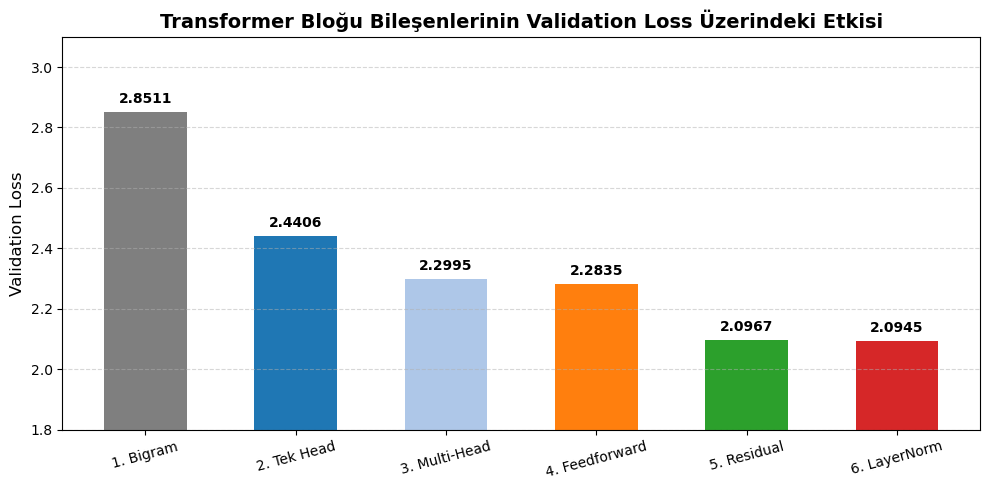

In [40]:
import matplotlib.pyplot as plt

stages = [
    "1. Bigram",
    "2. Tek Head",
    "3. Multi-Head",
    "4. Feedforward",
    "5. Residual",
    "6. LayerNorm"
]

val_losses = [2.8511, 2.4406, 2.2995, 2.2835, 2.0967, 2.0945]

plt.figure(figsize=(10, 5))
colors = ['#7f7f7f', '#1f77b4', '#aec7e8', '#ff7f0e', '#2ca02c', '#d62728']
bars = plt.bar(stages, val_losses, color=colors, width=0.55)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.ylabel('Validation Loss', fontsize=12)
plt.title('Transformer Bloğu Bileşenlerinin Validation Loss Üzerindeki Etkisi', fontsize=14, fontweight='bold')
plt.ylim(1.8, 3.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=15, fontsize=10)
plt.tight_layout()
plt.show()


### Tam Transformer Modelinden Örnek Metin Üretimi


In [41]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_text_ln = decode(model_ln.generate(context, max_new_tokens=500)[0].tolist())
print(generated_text_ln)



WARWICK:
Thou hast say he would but heart my heart;
And tell thy lord that good shall have made us to him.

KING EDWARD IV:
What is my father, is not he and some for thy brother,
Then good more heart have have not him to-night?

GLOUCESTER:
Why, sayst, I'll pray; this brother, were he is out?

KING RICHARD II:
Come, sir, not thy gentle friend, and take no man;
He may not will with heart and made of a son.

DUKE OF YORK:
Why, shall I make him to look on me?
He hath was a will not my hand be some so:
And make me brother, were I have he will say.
